<a href="https://colab.research.google.com/github/ahmadoarnaout-netizen/VIDEO-GAME-SALES-ANALYSIS/blob/main/VIDEO_GAME_SALES_ANALYSIS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **First Challenge: Studying Global Video Game Sales**


###**Problem Idetification**

To understand the video game sales better we need to take into account the following questions:

Which games sell the most?

Which genres and platforms perform better?

How sales differ by region?

How sales change over time?

## **Data Preparation**



In [ ]:
# Load libraries
install.packages("tidyverse")
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
#Creating a data frame by importing the data from a file
df <- read.csv("/content/vgsales.csv")
head(df)



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
2,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
3,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
4,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
5,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
6,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26


### **Check Structure**



In [ ]:
str(df)

'data.frame':	16598 obs. of  11 variables:
 $ Rank        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Name        : chr  "Wii Sports" "Super Mario Bros." "Mario Kart Wii" "Wii Sports Resort" ...
 $ Platform    : chr  "Wii" "NES" "Wii" "Wii" ...
 $ Year        : chr  "2006" "1985" "2008" "2009" ...
 $ Genre       : chr  "Sports" "Platform" "Racing" "Sports" ...
 $ Publisher   : chr  "Nintendo" "Nintendo" "Nintendo" "Nintendo" ...
 $ NA_Sales    : num  41.5 29.1 15.8 15.8 11.3 ...
 $ EU_Sales    : num  29.02 3.58 12.88 11.01 8.89 ...
 $ JP_Sales    : num  3.77 6.81 3.79 3.28 10.22 ...
 $ Other_Sales : num  8.46 0.77 3.31 2.96 1 0.58 2.9 2.85 2.26 0.47 ...
 $ Global_Sales: num  82.7 40.2 35.8 33 31.4 ...


In [ ]:
# Convert Year to numeric
df$Year<- as.numeric(as.character(df$Year))
summary(df$Year)

Warning message:
“NAs introduced by coercion”


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   1980    2003    2007    2006    2010    2020     271 

In [ ]:
class(df$Year)

[1] "numeric"

In [ ]:
# Check how many NAs are in the table
sum(is.na(df))

[1] 271

In [ ]:
colSums(is.na(df))

Rank         Name     Platform         Year        Genre    Publisher 
           0            0            0          271            0            0 
    NA_Sales     EU_Sales     JP_Sales  Other_Sales Global_Sales 
           0            0            0            0            0

In [ ]:
# Define fake NA values to look for
fake_na_values <- c("N/A", "NA", "na", "n.a.", "")

# Loop over columns and fake NA values
for (col in names(df)) {
  for (val in fake_na_values) {

    count <- sum(df[[col]] == val, na.rm = TRUE)

    if (count > 0) {
      cat("Found", count, "occurrences of '", val,
          "' in column:", col, "\n")
    }

  }
}

Found 58 occurrences of ' N/A ' in column: Publisher 


In [ ]:
# Replace fake NA values across the whole dataset
df[df == "N/A"] <- NA

In [ ]:
# Recheck for missing values
colSums(is.na(df))

Rank         Name     Platform         Year        Genre    Publisher 
           0            0            0          271            0           58 
    NA_Sales     EU_Sales     JP_Sales  Other_Sales Global_Sales 
           0            0            0            0            0

In [ ]:
# Remove rows that contain any NA values
df_clean <- na.omit(df)

In [ ]:
colSums(is.na(df_clean))

Rank         Name     Platform         Year        Genre    Publisher 
           0            0            0            0            0            0 
    NA_Sales     EU_Sales     JP_Sales  Other_Sales Global_Sales 
           0            0            0            0            0

In [ ]:
# Are there any duplicated rows?
sum(duplicated(df))

# View a few
df[duplicated(df), ]

[1] 0

Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
<int>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


### **Data Visualization**

#### **Game Releases Over Time**

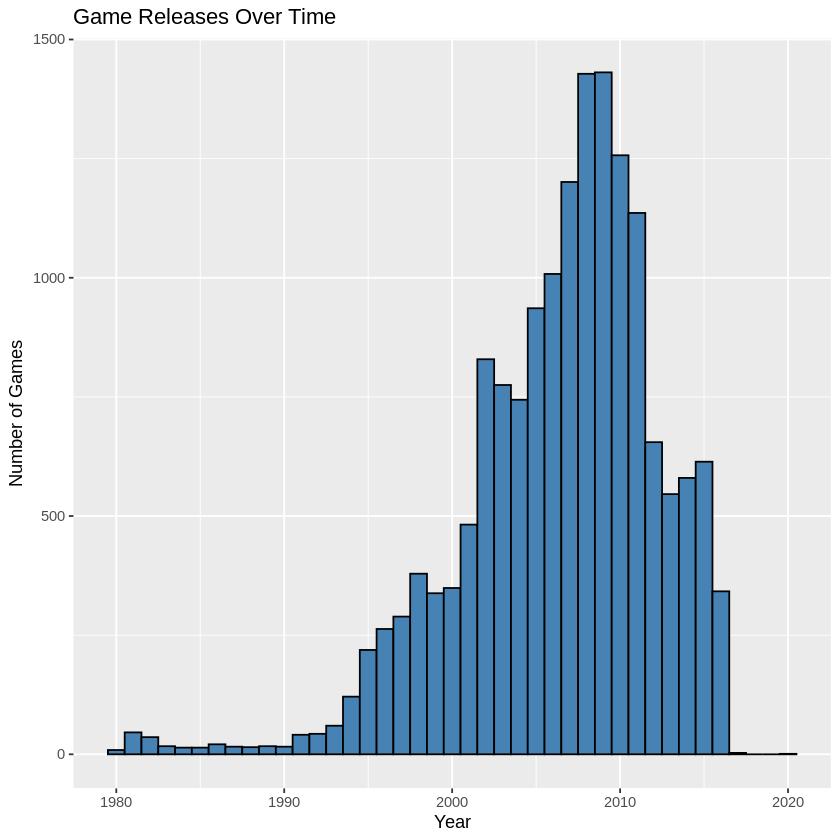

In [ ]:
# game releases over time
ggplot(df_clean, aes(x = Year)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "black") +
  labs(title = "Game Releases Over Time",
       x = "Year",
       y = "Number of Games")

#### **Top 10 Best Selling Games**

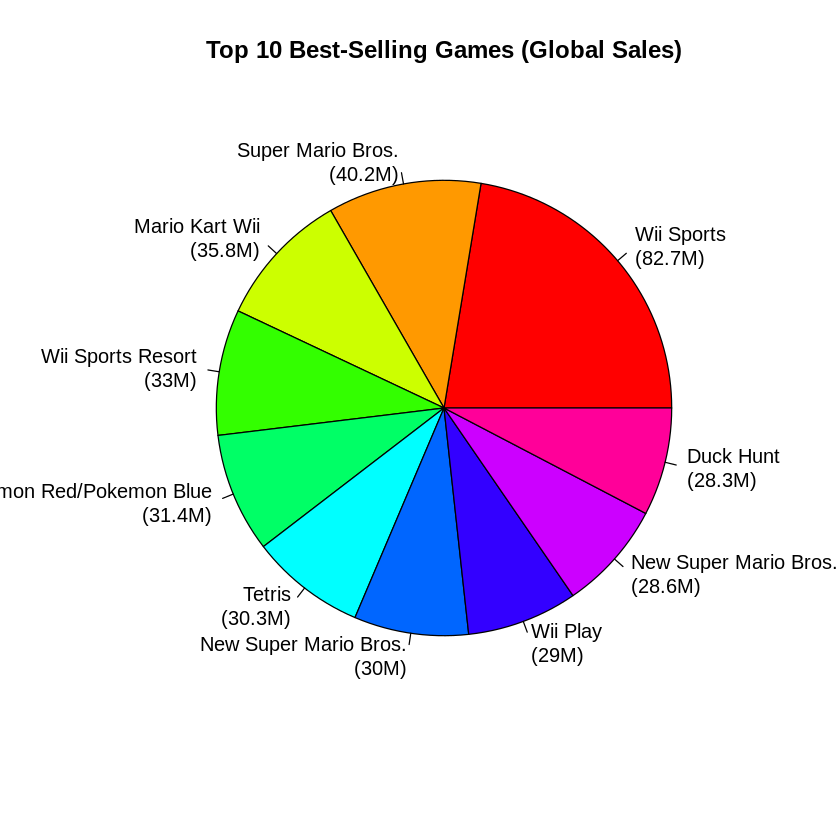

In [ ]:
# top 10 best selling games
top_games <- head(df_clean[order(-df_clean$Global_Sales), ], 10)

labels <- paste(top_games$Name,"\n(", round(top_games$Global_Sales, 1), "M)", sep = "")

pie(top_games$Global_Sales, labels = labels,
    main = "Top 10 Best-Selling Games (Global Sales)",
    col = rainbow(10))

#### **Global Sales by Platform**

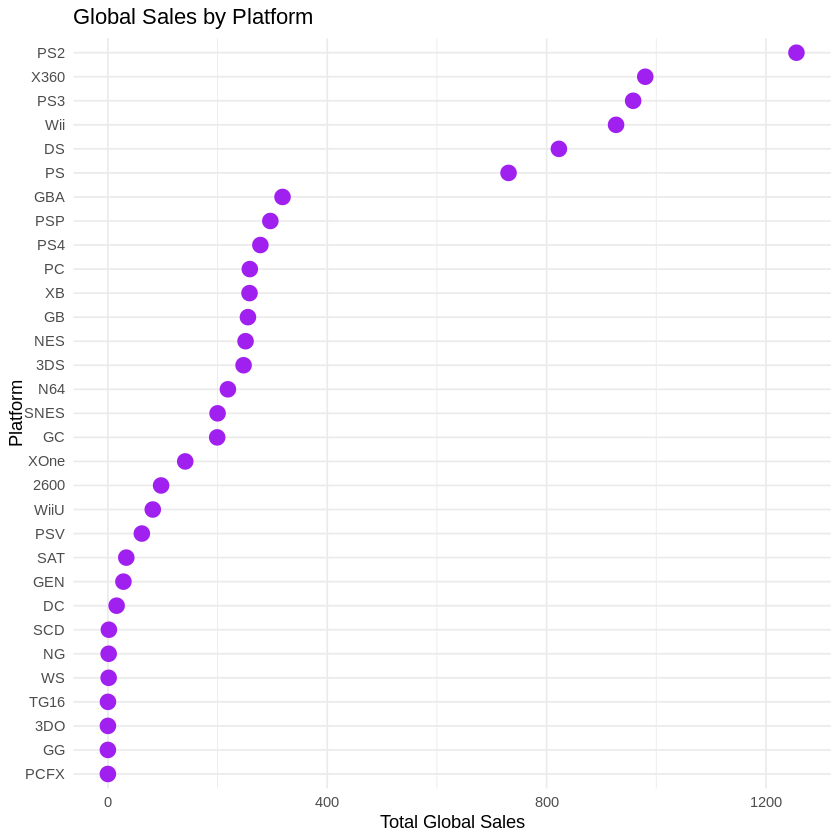

In [ ]:
# Global sales by platform
ggplot(platform_sales, aes(x = reorder(Platform, Global_Sales), y = Global_Sales)) +
  geom_point(size = 4, color = "purple") +
  coord_flip() +
  labs(title = "Global Sales by Platform", x = "Platform", y = "Total Global Sales") +
  theme_minimal()

#### **Global Sales by Year**

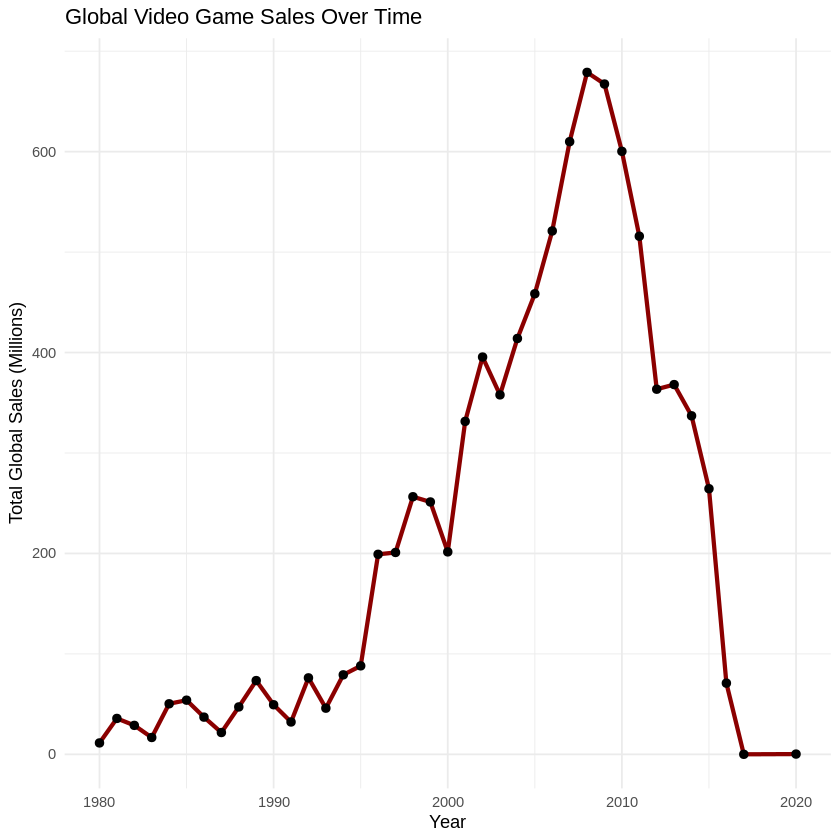

In [ ]:
# global sales by year
yearly_sales <- aggregate(Global_Sales ~ Year, data = df_clean, sum)

yearly_sales <- yearly_sales[order(yearly_sales$Year), ]

ggplot(yearly_sales, aes(x = Year, y = Global_Sales)) +
  geom_line(color = "darkred", size = 1.2) +
  geom_point(color = "black", size = 2) +
  labs(title = "Global Video Game Sales Over Time", x = "Year", y = "Total Global Sales (Millions)") +
  theme_minimal()

#### **Global Sales by Genre**

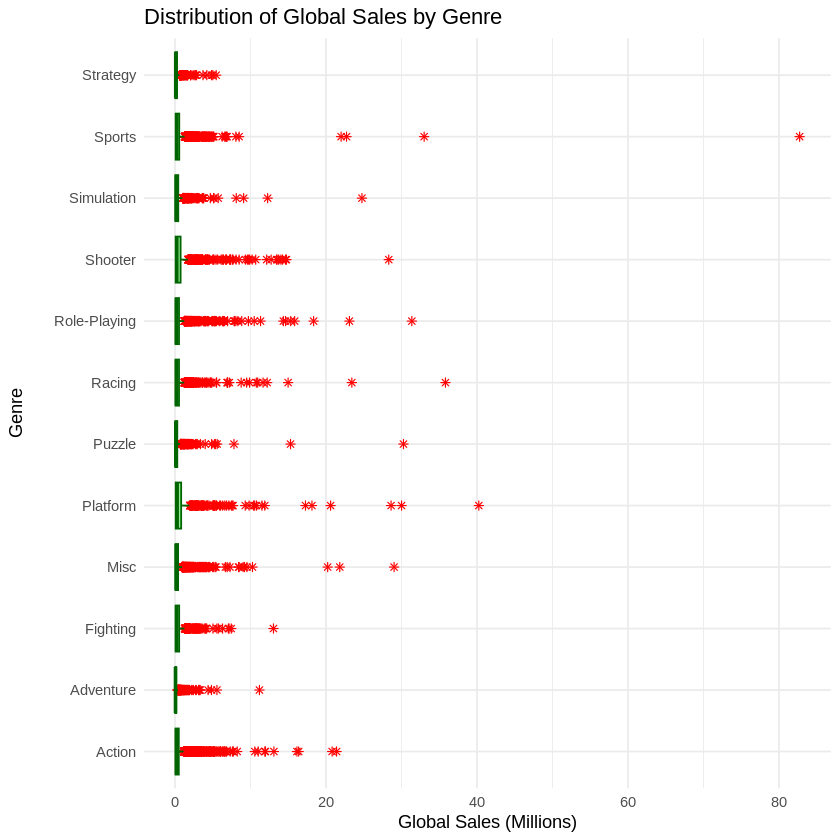

In [ ]:
# global sales by genre
ggplot(df_clean, aes(x = Genre, y = Global_Sales)) +
  geom_boxplot(fill = "lightgreen", color = "darkgreen", outlier.color = "red", outlier.shape = 8) +
  coord_flip() +
  labs(title = "Distribution of Global Sales by Genre",
       x = "Genre",
       y = "Global Sales (Millions)") +
  theme_minimal()

### **Key Metrics**

#### **Top Selling Game**

In [ ]:
# Top selling game
top_game <- df_clean[df_clean$Global_Sales == max(df_clean$Global_Sales, na.rm = TRUE), ]

cat("Top-Selling Game:\n", top_game$Name, "\n")

Top-Selling Game:
 Wii Sports 


#### **Least Selling Game (excluding 0)**



In [ ]:
# Least selling game (excluding 0)
least_game <- df_clean[df_clean$Global_Sales == min(df_clean$Global_Sales[df_clean$Global_Sales > 0], na.rm = TRUE), ]

cat("Least-Selling Game:\n", least_game$Name, "\n")

Least-Selling Game:
 Turok Coven and Labyrinth of Refrain Super Battle For Money Sentouchuu: Kyuukyoku no Shinobu to Battle Player Choujou Kessen! Dragon Zakura DS Chameleon: To Dye For! Hotel Giant DS Sora no Otoshimono: DokiDoki Summer Vacation Blackthorne Don Bradman Cricket 14 DokuSui: DokiDoki Suikoden Shinseiki Evangelion: Battle Orchestra Portable Donkey Kong Jungle Beat Bomberman (jp sales) Blazblue: Continuum Shift Extend S.Y.K: Shinsetsu Saiyuuki Football Manager Live Captain Morgane and the Golden Turtle Black Cat One Piece: Daikaizoku Coliseum Mortal Kombat Smart Kid's Mega Game Mix Diary Girl Red Stone DS: Akaki Ishi ni Michibikareshi Monotachi Serious Sam II Wand of Fortune: Mirai e no Prologue Portable Sengoku Hime: Senran ni Mau Otometachi Secret Game Portable Demon Gaze 2 Neverwinter Nights 2: Mask of the Betrayer Kimi no Yuusha Call of Juarez Tom Clancy's  Ghost Recon Advanced Warfighter (weekly JP sales) UEFA Champions League 2006-2007 Codename: Panzers Phase Two Nob

#### **Top and Least Selling Genres**

In [ ]:
# top and least selling genres
genre_totals <- aggregate(Global_Sales ~ Genre, df_clean, sum)

top_genre <- genre_totals[which.max(genre_totals$Global_Sales), ]
least_genre <- genre_totals[which.min(genre_totals$Global_Sales), ]

cat("Top Genre by Global Sales:\n")
print(top_genre)

cat("\nLeast Genre by Global Sales:\n")
print(least_genre)

Top Genre by Global Sales:
   Genre Global_Sales
1 Action      1722.84

Least Genre by Global Sales:
      Genre Global_Sales
12 Strategy       173.27


#### **Top and Least Selling Platforms**

In [ ]:
# top and least selling platforms
platform_totals <- aggregate(Global_Sales ~ Platform, df_clean, sum)

top_platform <- platform_totals[which.max(platform_totals$Global_Sales), ]
least_platform <- platform_totals[which.min(platform_totals$Global_Sales), ]

cat("Top Platform by Global Sales:\n")
print(top_platform)

cat("\nLeast Platform by Global Sales:\n")
print(least_platform)

Top Platform by Global Sales:
   Platform Global_Sales
17      PS2      1233.46

Least Platform by Global Sales:
   Platform Global_Sales
15     PCFX         0.03


#### **Regional Performance Analysis**

In [ ]:
# Regional Performance Analysis
region_totals <- colSums(df_clean[, c("NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales")])

region_totals <- round(region_totals, 1)

cat("Regional Sales Summary\n")
cat(paste("North America:", region_totals["NA_Sales"], "million units\n"))
cat(paste("Europe:", region_totals["EU_Sales"], "million units\n"))
cat(paste("Japan:", region_totals["JP_Sales"], "million units\n"))
cat(paste("Other Regions:", region_totals["Other_Sales"], "million units\n"))

Regional Sales Summary
North America: 4327.6 million units
Europe: 2406.7 million units
Japan: 1284.3 million units
Other Regions: 788.9 million units
